In [17]:
import numpy as np 
import matplotlib.pyplot as plt

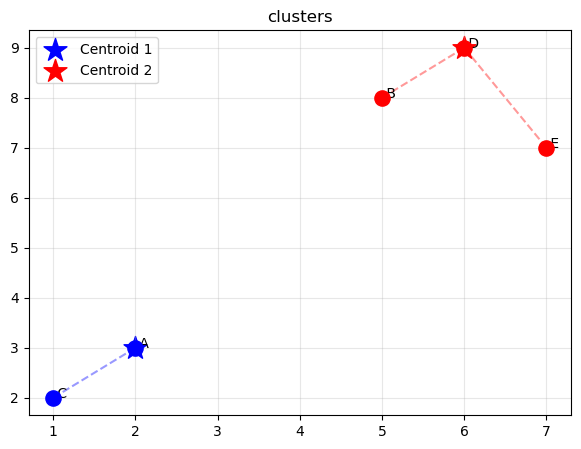

In [18]:
#task-1 Plot Points & Manually Assign Clusters

import numpy as np
import matplotlib.pyplot as plt

points = np.array([[2,3],[5,8],[1,2],[6,9],[7,7]])
C1, C2 = points[0], points[3]

def euclidean(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

assignments = []
for point in points:
    d1 = euclidean(point, C1)
    d2 = euclidean(point, C2)
    assignments.append(0 if d1 < d2 else 1)

colors = ['blue' if a == 0 else 'red' for a in assignments]
labels = ['A','B','C','D','E']

plt.figure(figsize=(7,5))
for i, (p, c, l) in enumerate(zip(points, colors, labels)):
    plt.scatter(p[0], p[1], color=c, s=120, zorder=5)
    plt.annotate(f' {l}', p, fontsize=10)

plt.scatter(*C1, color='blue', s=300, marker='*', label='Centroid 1')
plt.scatter(*C2, color='red',  s=300, marker='*', label='Centroid 2')

for p, a in zip(points, assignments):
    centroid = C1 if a == 0 else C2
    plt.plot([p[0], centroid[0]], [p[1], centroid[1]], '--',
             color='blue' if a == 0 else 'red', alpha=0.4)

plt.title('clusters')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
#task-2 
import numpy as np

def assign_clusters(points, centroids):
    assignments = []
    for point in points:
        distances = [np.sqrt(np.sum((np.array(point) - np.array(c))**2)) for c in centroids]
        assignments.append(distances.index(min(distances)))
    return assignments


points    = [[2,3],[5,8],[1,2],[6,9],[7,7]]
centroids = [[2,3],[6,9]]

print(assign_clusters(points, centroids))

[0, 1, 0, 1, 1]


In [20]:
#task-3

import numpy as np

def assign_clusters(points, centroids, distance='euclidean'):
    def euclidean(p1, p2):
        return np.sqrt(np.sum((np.array(p1) - np.array(p2))**2))

    def manhattan(p1, p2):
        return np.sum(np.abs(np.array(p1) - np.array(p2)))

    dist_func = euclidean if distance == 'euclidean' else manhattan

    assignments = []
    for point in points:
        distances = [dist_func(point, c) for c in centroids]
        assignments.append(distances.index(min(distances)))
    return assignments


points    = [[2,3],[5,8],[1,2],[6,9],[7,7]]
centroids = [[2,3],[6,9]]

print('Euclidean:', assign_clusters(points, centroids, distance='euclidean'))
print('Manhattan:', assign_clusters(points, centroids, distance='manhattan'))


Euclidean: [0, 1, 0, 1, 1]
Manhattan: [0, 1, 0, 1, 1]


In [21]:
#task 4 

import numpy as np

def update_centroids(points, assignments, k):
    points = np.array(points)
    new_centroids = []
    
    for cluster_id in range(k):
        cluster_points = points[np.array(assignments) == cluster_id]
        new_centroids.append(np.mean(cluster_points, axis=0).tolist())
    
    return new_centroids


points      = [[2,3], [5,8], [1,2], [6,9], [7,7]]
assignments = [0, 1, 0, 1, 1]
k           = 2

print(update_centroids(points, assignments, k))

[[1.5, 2.5], [6.0, 8.0]]


In [ ]:
#task-5
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler

In [27]:
data = np.array ([
    # Budget restaurants
    [3.2, 150], [3.5, 180], [3.1, 120], [3.8, 200], [3.3, 160],
    [3.6, 175], [3.0, 130], [3.4, 190], [3.7, 210], [3.2, 145],
    # Mid-range restaurants
    [4.0, 450], [4.2, 500], [4.1, 480], [4.3, 520], [4.0, 460],
    [4.4, 510], [4.2, 490], [4.1, 470], [4.3, 530], [4.0, 440],
    # Premium restaurants
    [4.6, 900], [4.7, 950], [4.8, 1100], [4.5, 850], [4.9, 1200],
    [4.6, 980], [4.7, 1050],[4.8, 1150], [4.5, 880], [4.9, 1300],
])

In [28]:
data_scaled = StandardScaler().fit_transform(data)

data_scaled

array([[-1.53748443, -1.11640235],
       [-1.01334201, -1.03517663],
       [-1.71219857, -1.19762807],
       [-0.48919959, -0.98102616],
       [-1.36277029, -1.08932711],
       [-0.83862787, -1.04871425],
       [-1.88691271, -1.17055283],
       [-1.18805615, -1.00810139],
       [-0.66391373, -0.95395092],
       [-1.53748443, -1.12993997],
       [-0.13977131, -0.30414518],
       [ 0.20965697, -0.16876899],
       [ 0.03494283, -0.22291947],
       [ 0.38437111, -0.11461851],
       [-0.13977131, -0.27706994],
       [ 0.55908525, -0.14169375],
       [ 0.20965697, -0.19584423],
       [ 0.03494283, -0.24999471],
       [ 0.38437111, -0.08754327],
       [-0.13977131, -0.33122042],
       [ 0.90851353,  0.91424057],
       [ 1.08322766,  1.04961676],
       [ 1.2579418 ,  1.45574534],
       [ 0.73379939,  0.77886437],
       [ 1.43265594,  1.72649773],
       [ 0.90851353,  1.13084248],
       [ 1.08322766,  1.32036915],
       [ 1.2579418 ,  1.59112154],
       [ 0.73379939,

In [31]:
#elbow method 

wcss = []

for k in range(1,7):
    km = KMeans (n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(data_scaled)
    wcss.append(km.inertia_)

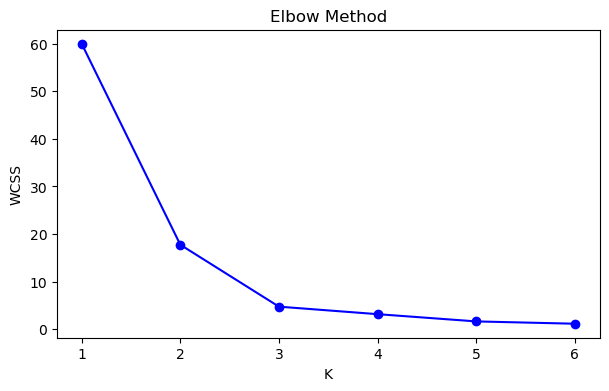

In [32]:
plt.figure(figsize=(7,4))
plt.plot(range(1, 7), wcss, 'bo-')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.show()
